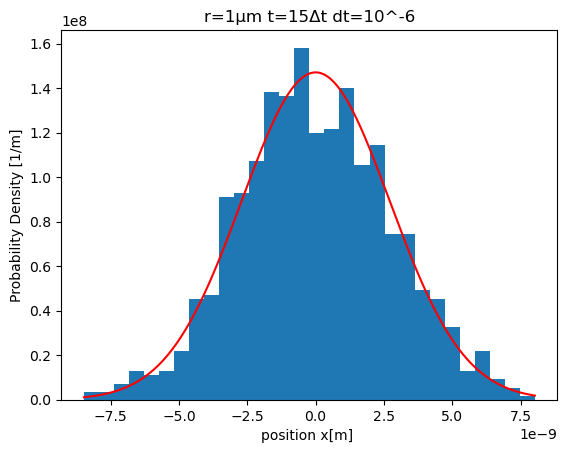

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-6)
steps=15

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-6)             #半径 100μm
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間         

x=np.zeros(n)
v=np.zeros(n)
data=[]                    

#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

for _ in range(n):
    x=0
    v=0
    
    for _ in range(1,steps+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
        # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
        sigma=np.sqrt(2*kB*T*q*dt)     #標準偏差
        f_random=random.gauss(0,sigma)

        dv=-beta*v*dt+f_random/m
        v=v+dv
        x=x+v*dt
    data.append(x)

plt.hist(data,bins=30,density=True)
plt.title("r=1μm t=15Δt dt=10^-6")

#理論ガウス曲線を描く

D=(kB*T)/q
t_fin=steps*dt
x_min,x_max=min(data),max(data)
x_theory=np.linspace(x_min,x_max,200)
sigma_theory=np.sqrt(2*D*t_fin)
f_gauss=(1/(np.sqrt(2*np.pi)*sigma_theory))*np.exp(-x_theory**2/(2*sigma_theory**2))
plt.xlabel("position x[m] ")
plt.ylabel("Probability Density [1/m]")

plt.plot(x_theory,f_gauss,color='red')
plt.show()

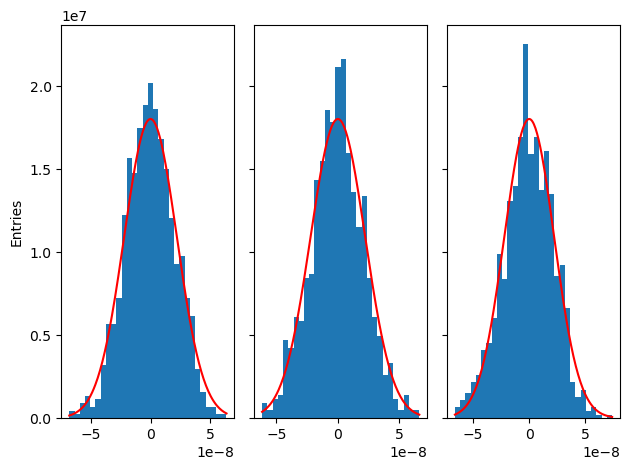

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-4)
dt_list=[15*dt,30*dt,50*dt]
t_fin=0.1

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-4)             #半径 100μm
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間         
D=(kB*T)/q
                 

#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

fig,axes=plt.subplots(1,3,sharey=True)

for i in range(3):
    dt_keisann=dt_list[i]
    steps=int(t_fin/dt_keisann)     #ステップ数を整数にする
    ax=axes[i]

    data=[]
    
    for _ in range(n):
        x=0
        v=0
    
        for _ in range(1,steps+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
            # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
            sigma=np.sqrt(2*kB*T*q*dt_keisann)     #標準偏差
            f_random=random.gauss(0,sigma)

            dv=-beta*v*dt_keisann+f_random/m
            v=v+dv
            x=x+v*dt_keisann
        data.append(x)

    ax.hist(data,bins=30,density=True)

    #理論ガウス曲線を描く

    x_min,x_max=min(data),max(data)
    x_theory=np.linspace(x_min,x_max,200)
    sigma_theory=np.sqrt(2*D*t_fin)
    f_gauss=(1/(np.sqrt(2*np.pi)*sigma_theory))*np.exp(-x_theory**2/(2*sigma_theory**2))
    ax.plot(x_theory,f_gauss,color='red')

axes[0].set_ylabel("Entries")
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


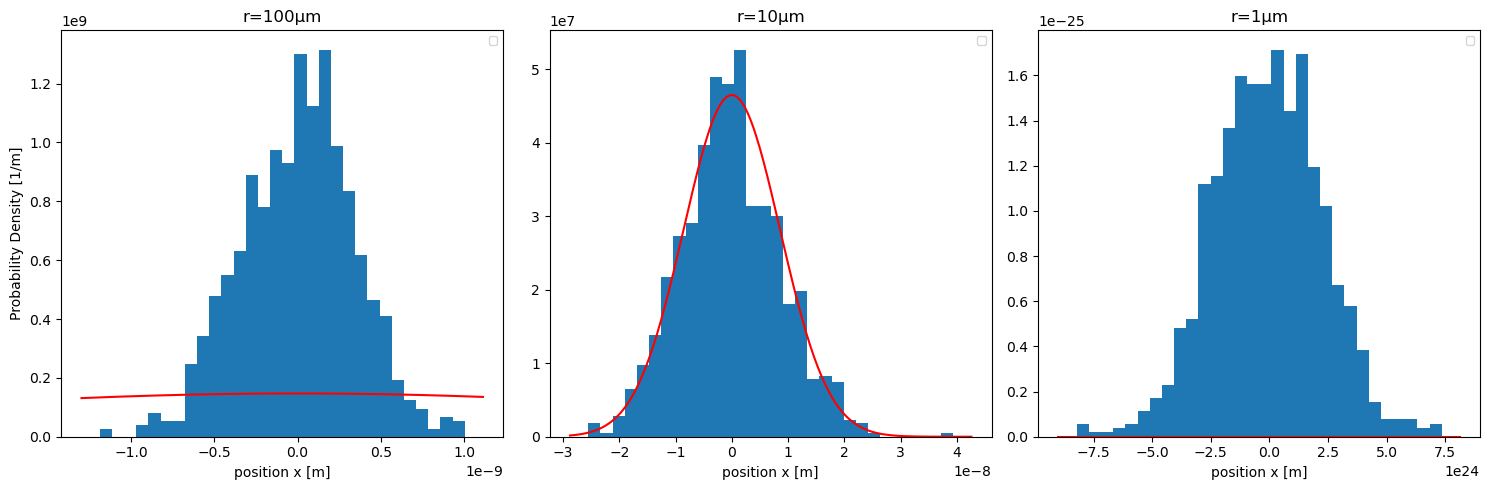

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 基本設定
n = 1000                  # 粒子数
dt = 1.0*10**(-4)
steps_keisann = 15     # すべて15ステップで固定
t_now = steps_keisann * dt

kB = 1.38*10**(-23)       # ボルツマン定数
T = 273 + 25              # 温度 25℃
rho = 2699                # 密度 [kg/m^3]
visc = 0.890*10**(-3)     # 粘性係数

# 半径のリスト
r_list = [1.0*10**(-4), 1.0*10**(-5), 1.0*10**(-6)] # 100μm, 10μm, 1μm
r_labels = ["100μm", "10μm", "1μm"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i in range(3):
    r = r_list[i]
    ax = axes[i]
    
    # 物理パラメータの再計算
    m = rho * (4/3) * np.pi * r**3
    q = visc * 6 * np.pi * r
    beta = q / m
    tau = 1 / beta          # 緩和時間
    D = (kB * T) / q
    
    data = []
    for _ in range(n):
        x = 0
        v = 0
        for _ in range(1, steps_keisann + 1):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v = v + dv
            x = x + v * dt
        data.append(x)
    
    # ヒストグラムの描画
    ax.hist(data, bins=30, density=True)
    
    # 理論ガウス曲線（拡散領域の式）
    x_min, x_max = ax.get_xlim()
    x_theory = np.linspace(x_min, x_max, 200)
    sigma_theory = np.sqrt(2 * D * t_now)
    f_gauss = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-x_theory**2 / (2 * sigma_theory**2))
    
    ax.plot(x_theory, f_gauss, color='red')
    
    # ラベル・タイトル設定
    ax.set_xlabel("position x [m]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    # 1枚目にだけ縦軸ラベル
    if i == 0:
        ax.set_ylabel("Probability Density [1/m]")
    
    ax.legend(fontsize=8)
axes[0].set_title("r=100μm")
axes[1].set_title("r=10μm")
axes[2].set_title("r=1μm")
plt.tight_layout()
plt.show()

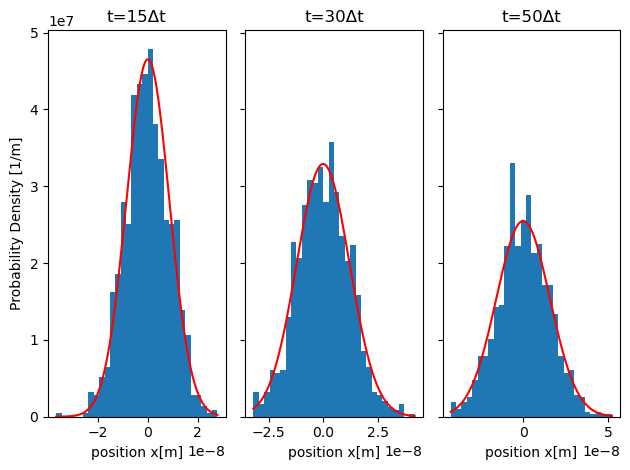

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-4)
steps_list=[15,30,50]

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-5)             #半径 10μm  1.0*10^-4,1.0*10^-6では理論値と一致しなかった。
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間         
D=(kB*T)/q
                 

#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

fig,axes=plt.subplots(1,3,sharey=True)

for i in range(3):
    steps_keisann=steps_list[i]
    t_now=steps_keisann*dt
    ax=axes[i]

    data=[]
    
    for _ in range(n):
        x=0
        v=0
    
        for _ in range(1,steps_keisann+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
            # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
            sigma=np.sqrt(2*kB*T*q*dt)     #標準偏差
            f_random=random.gauss(0,sigma)

            dv=-beta*v*dt+f_random/m
            v=v+dv
            x=x+v*dt
        data.append(x)

    ax.hist(data,bins=30,density=True)

    #理論ガウス曲線を描く

    x_min,x_max=min(data),max(data)
    x_theory=np.linspace(x_min,x_max,200)
    sigma_theory=np.sqrt(2*D*t_now)
    f_gauss=(1/(np.sqrt(2*np.pi)*sigma_theory))*np.exp(-x_theory**2/(2*sigma_theory**2))
    ax.plot(x_theory,f_gauss,color='red')
    ax.set_xlabel("position x[m]")

axes[0].set_ylabel("Probability Density [1/m]")
axes[0].set_title("t=15Δt")
axes[1].set_title("t=30Δt")
axes[2].set_title("t=50Δt")
plt.tight_layout()
plt.show()

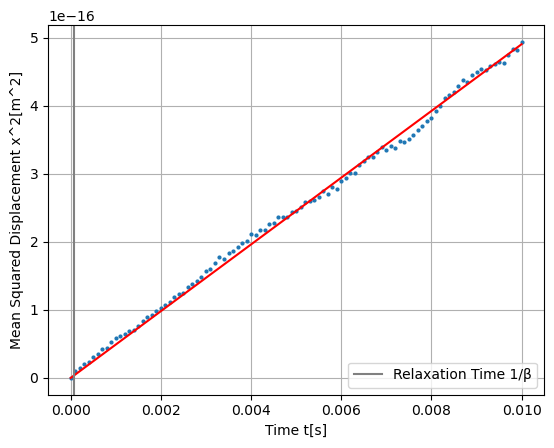

理論上の拡散係数　D： 2.4513437751726976e-14
グラフから求めた拡散係数　D： 2.4681200859183662e-14


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-4)
steps=100

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-5)             #半径 10μm      1.0*10^-4,1.0*10^-6では理論値と一致しなかった。
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間      
D_theory=(kB*T)/q

x2_sum=np.zeros(steps+1)                  

#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

for _ in range(n):
    x=0
    v=0
    
    for i in range(1,steps+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
        # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
        sigma=np.sqrt(2*kB*T*q*dt)     #標準偏差
        f_random=random.gauss(0,sigma)

        dv=-beta*v*dt+f_random/m
        v=v+dv
        x=x+v*dt
        x2_sum[i]+=x**2

x2_av=x2_sum/n
time_theory=np.linspace(0,steps*dt,steps+1)

plt.plot(time_theory,x2_av,"o",markersize=2)

plt.plot(time_theory,2*D_theory*time_theory,color="red")
plt.axvline(x=1/beta,color="gray",label="Relaxation Time 1/β")
plt.xlabel("Time t[s]")
plt.ylabel("Mean Squared Displacement x^2[m^2]")
plt.legend()
plt.grid(True)
plt.show()

D_ex=x2_av[-1]/(2*(steps*dt))
print("理論上の拡散係数　D：",D_theory)
print("グラフから求めた拡散係数　D：",D_ex)

理論上の拡散係数　D： 2.4513437751726976e-14
グラフから求めた拡散係数　D： 2.4681200859183662e-14



<function matplotlib.pyplot.show(close=None, block=None)>

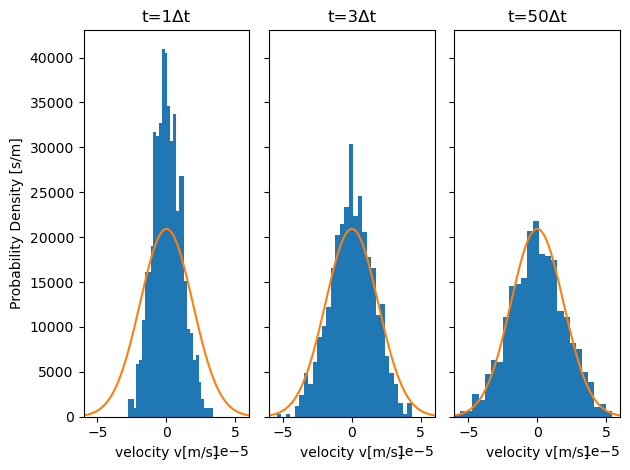

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-5)
steps_list=[1,3,50]

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-5)             #半径 10μm  1.0*10^-4,1.0*10^-6では理論値と一致しなかった。
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間         
D=(kB*T)/q

sigma_v_theory=np.sqrt(kB*T/m)
                 
#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

fig,axes=plt.subplots(1,3,sharey=True)
v_limit=6.0*10**(-5)

for i in range(3):
    steps_keisann=steps_list[i]
    ax=axes[i]

    data=[]
    
    for _ in range(n):
        x=0
        v=0
    
        for _ in range(1,steps_keisann+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
            # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
            sigma=np.sqrt(2*kB*T*q*dt)     #標準偏差
            f_random=random.gauss(0,sigma)

            dv=-beta*v*dt+f_random/m
            v=v+dv
            x=x+v*dt
        data.append(v)

    ax.hist(data,bins=30,density=True)

    v_theory=np.linspace(-v_limit,v_limit,200)
    f_maxwell=(1/(np.sqrt(2*np.pi)*sigma_v_theory))*np.exp((-v_theory**2)/(2*sigma_v_theory**2))

    ax.plot(v_theory,f_maxwell,"-")
    ax.set_xlabel("velocity v[m/s]")
    ax.set_xlim(-v_limit,v_limit)
    
axes[0].set_ylabel("Probability Density [s/m]")
axes[0].set_title("t=1Δt")
axes[1].set_title("t=3Δt")
axes[2].set_title("t=50Δt")
plt.tight_layout()
plt.show



In [ ]:
#縦軸がEntriesのバージョン（位置ｘ）を書く

<function matplotlib.pyplot.show(close=None, block=None)>

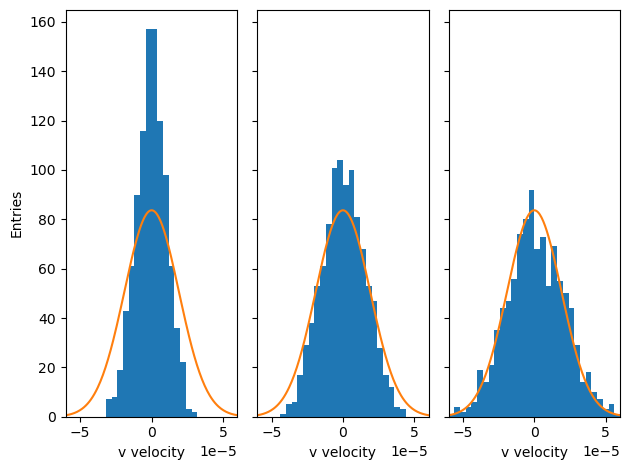

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import random

#位置と速度の更新をforで回す。

n=1000                     #粒子数
dt=1.0*10**(-5)
steps_list=[1,3,50]

kB=1.38*10**(-23)          #ボルツマン定数
T=273+25                   #温度 25℃
r=1.0*10**(-5)             #半径 10μm  1.0*10^-4,1.0*10^-6では理論値と一致しなかった。
rho=2699                   #密度 [kg/m^3]
visc=0.890*10**(-3)        #粘性係数

m=rho*(4/3)*np.pi*r**3     #質量
q=visc*6*np.pi*r           #粘性抵抗                  
beta=q/m                   #1/betaが緩和時間         
D=(kB*T)/q

sigma_v_theory=np.sqrt(kB*T/m)
                 
#粒子を１つずつループ（外）
#その粒子の時間をステップごとに進める（内）

fig,axes=plt.subplots(1,3,sharey=True)
v_limit=6.0*10**(-5)
bins_num=30

for i in range(3):
    steps_keisann=steps_list[i]
    ax=axes[i]

    data=[]
    
    for _ in range(n):
        x=0
        v=0
    
        for _ in range(1,steps_keisann+1):         #0の状態がすでに決まっているのと、ステップ数がわかりやすいので1から始める
            # D=(kB*T)/q , <x^2>=2Dt   ,(sigma^2/q^2)=(2kB*T/q*dt)
            sigma=np.sqrt(2*kB*T*q*dt)     #標準偏差
            f_random=random.gauss(0,sigma)

            dv=-beta*v*dt+f_random/m
            v=v+dv
            x=x+v*dt
        data.append(v)

    ax.hist(data,bins=bins_num,range=(-v_limit,v_limit))
    
    v_theory=np.linspace(-v_limit,v_limit,200)
    f_maxwell=(1/(np.sqrt(2*np.pi)*sigma_v_theory))*np.exp((-v_theory**2)/(2*sigma_v_theory**2))

    bins_haba=(2*v_limit)/bins_num
    f_entries=f_maxwell*n*bins_haba

    ax.plot(v_theory,f_entries,"-")
    ax.set_xlabel("v velocity")
    ax.set_xlim(-v_limit,v_limit)
    
axes[0].set_ylabel("Entries")
plt.tight_layout()
plt.show



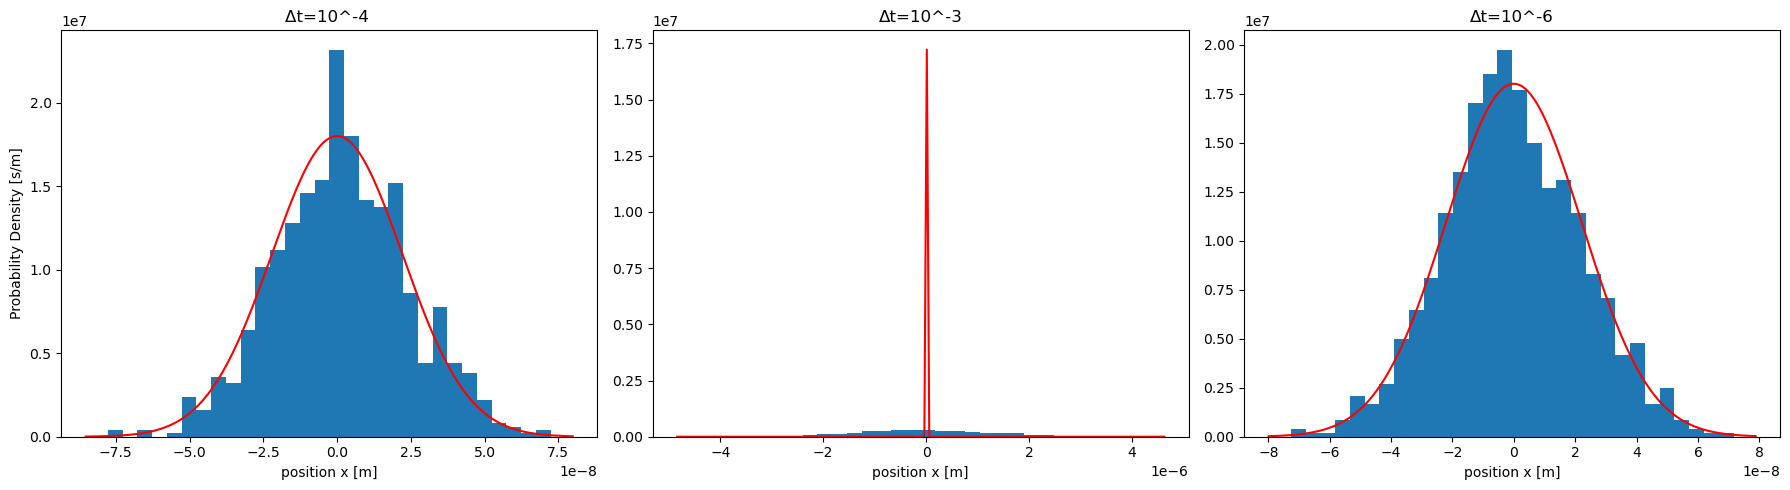

52.042479515075684
緩和時間τは約 6.74e-05 秒


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# 基本物理パラメータ (10μmの粒子を基準にする)
n = 1000
kB = 1.38*10**(-23)
T = 273 + 25
r = 1.0*10**(-5)  # 10μm
rho = 2699
visc = 0.890*10**(-3)

m = rho * (4/3) * np.pi * r**3
q = visc * 6 * np.pi * r
beta = q / m
tau = 1 / beta
D = (kB * T) / q

# 比較する dt のリスト
# 1. 適切 (dt << tau)
# 2. 大きすぎる (dt が tau に近い、または超える)
# 3. 極端に小さすぎる (ステップ数が膨大になる)
dt_list = [1.0*10**(-4), 1.0*10**(-3), 1.0*10**(-6)]
steps_list = [100, 2, 10000] # 合計のシミュレーション時間を約0.01秒に合わせる

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    dt = dt_list[i]
    steps = steps_list[i]
    t_fin = dt * steps
    ax = axes[i]

    start_time = time.time()
    
    data = []
    for _ in range(n):
        x = 0
        v = 0
        for _ in range(1, steps + 1):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v = v + dv
            x = x + v * dt
        data.append(x)

    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # ヒストグラム
    ax.hist(data, bins=30, density=True)
    
    # 理論曲線
    x_min, x_max = ax.get_xlim()
    x_theory = np.linspace(x_min, x_max, 200)
    sigma_theory = np.sqrt(2 * D * t_fin)
    f_gauss = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-x_theory**2 / (2 * sigma_theory**2))
    
    ax.plot(x_theory, f_gauss, color='red')
    
    # 装飾
    ax.set_xlabel("position x [m]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if i == 0:
        ax.set_ylabel("Probability Density [s/m]")
        
axes[0].set_title("Δt=10^-4 ")
axes[1].set_title("Δt=10^-3")
axes[2].set_title("Δt=10^-6")
plt.tight_layout()
plt.show()
print( elapsed_time)

print(f"緩和時間τは約 {tau:.2e} 秒")

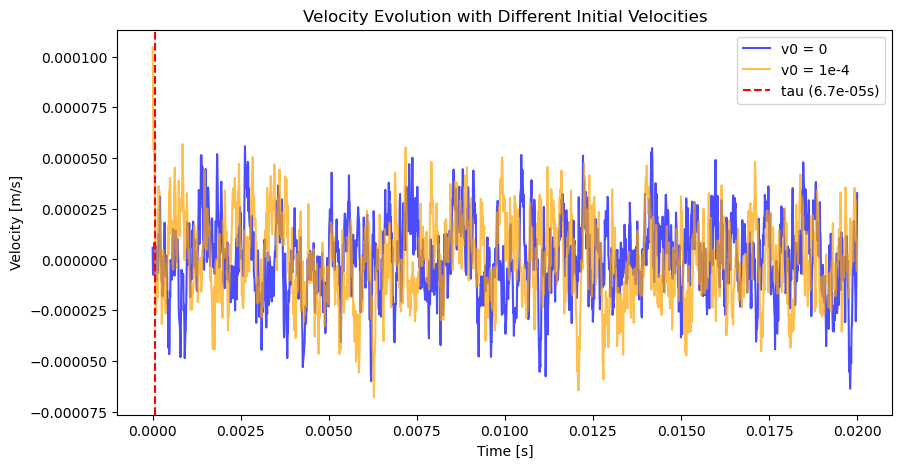

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 物理パラメータ (10μm粒子)
dt = 1.0*10**(-5)
steps = 2000
t_axis = np.linspace(0, dt*steps, steps)

# 粒子設定
v0_list = [0.0, 1e-4] # 静止状態と、大きな初速度
colors = ['blue', 'orange']
labels = ['v0 = 0', 'v0 = 1e-4']

plt.figure(figsize=(10, 5))

for v0, color, label in zip(v0_list, colors, labels):
    v = v0
    v_history = []
    for _ in range(steps):
        sigma = np.sqrt(2 * kB * T * q * dt)
        f_random = np.random.normal(0, sigma)
        dv = -beta * v * dt + f_random / m
        v = v + dv
        v_history.append(v)
    
    plt.plot(t_axis, v_history, color=color, alpha=0.7, label=label)

# 緩和時間 tau を縦線で表示
plt.axvline(x=tau, color='red', linestyle='--', label=f'tau ({tau:.1e}s)')
plt.title("Velocity Evolution with Different Initial Velocities")
plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.show()

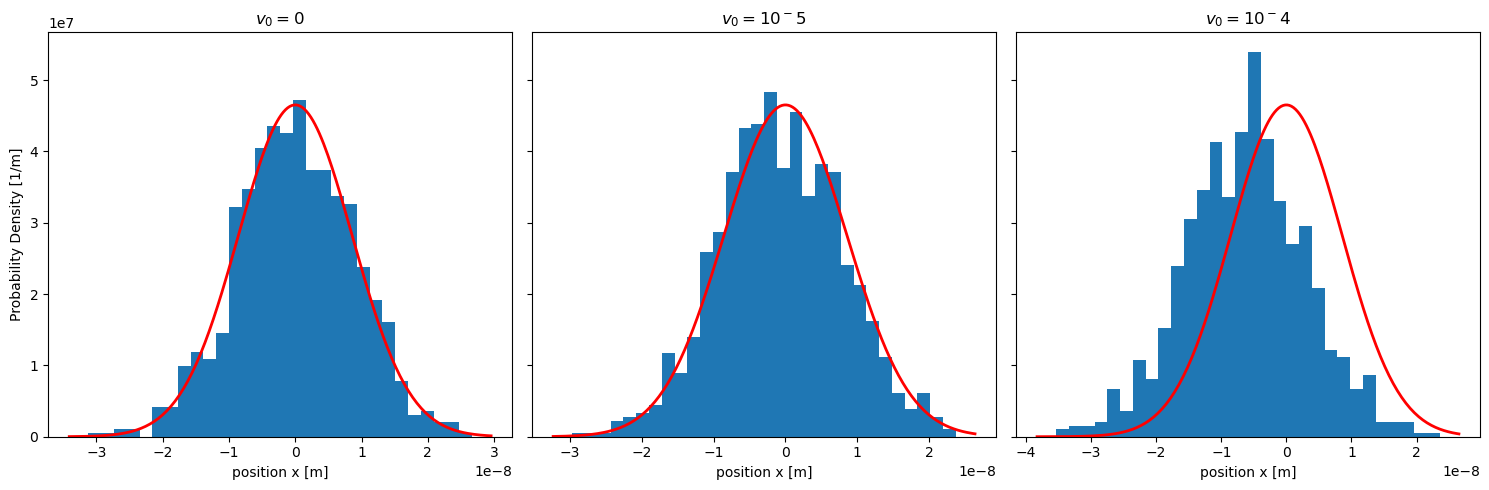

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 基本物理パラメータ (10μm粒子)
n = 1000
dt = 1.0*10**(-4)
steps_keisann = 15
t_now = steps_keisann * dt

kB = 1.38*10**(-23)
T = 273 + 25
r = 1.0*10**(-5)  # 10μm
rho = 2699
visc = 0.890*10**(-3)

m = rho * (4/3) * np.pi * r**3
q = visc * 6 * np.pi * r
beta = q / m
D = (kB * T) / q

# 初速度の設定
v_rms = np.sqrt(kB * T / m) # 熱速度 (約 1.0e-5)
v0_list = [0, v_rms, v_rms * 10] 
v0_labels = ["$v_0 = 0$", "$v_0 = 10^-5$", "$v_0 = 10^-4$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i in range(3):
    v0 = v0_list[i]
    ax = axes[i]
    
    data = []
    for _ in range(n):
        x = 0
        v = v0 # 各粒子の初速度を設定
        for _ in range(1, steps_keisann + 1):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v = v + dv
            x = x + v * dt
        data.append(x)
    
    # ヒストグラム
    ax.hist(data, bins=30, density=True)
    
    # 理論ガウス曲線 (定常状態の拡散式)
    x_min, x_max = ax.get_xlim()
    x_theory = np.linspace(x_min, x_max, 200)
    sigma_theory = np.sqrt(2 * D * t_now)
    f_gauss = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-x_theory**2 / (2 * sigma_theory**2))
    
    ax.plot(x_theory, f_gauss, color='red', lw=2)
    
    # 設定
    ax.set_title(f"{v0_labels[i]}")
    ax.set_xlabel("position x [m]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if i == 0:
        ax.set_ylabel("Probability Density [1/m]")

plt.tight_layout()
plt.show()

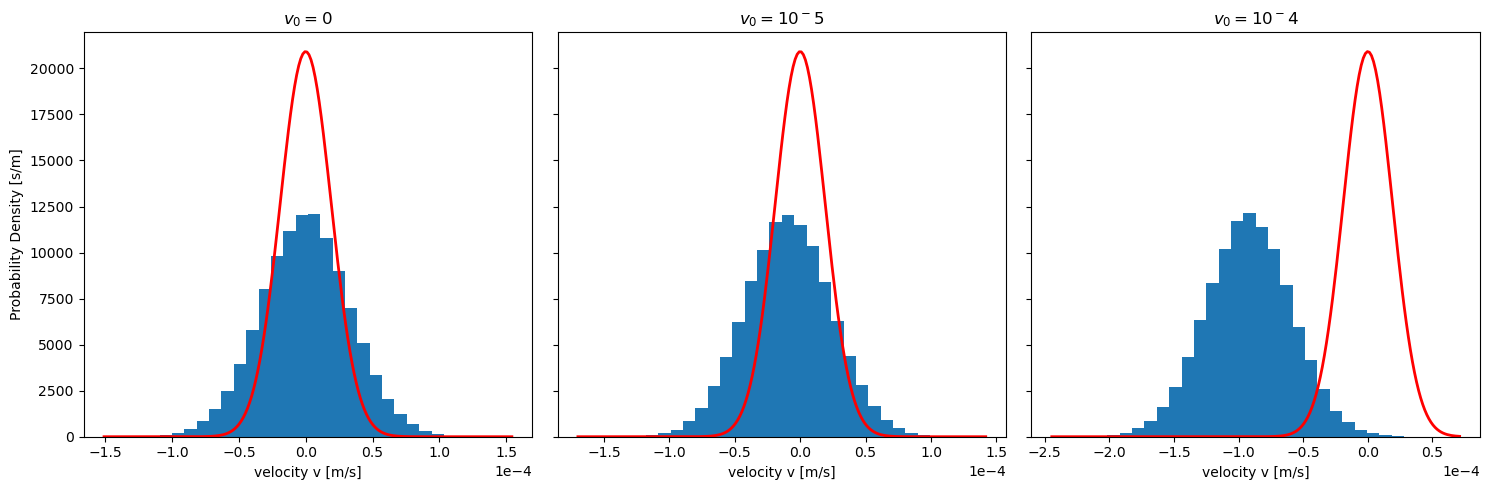

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 基本物理パラメータ (10μm粒子)
n = 1000
dt = 1.0*10**(-4)
steps_keisann = 1
t_now = steps_keisann * dt

kB = 1.38*10**(-23)
T = 273 + 25
r = 1.0*10**(-5)  # 10μm
rho = 2699
visc = 0.890*10**(-3)

m = rho * (4/3) * np.pi * r**3
q = visc * 6 * np.pi * r
beta = q / m
tau = 1 / beta

# 初速度の設定 (前回の位置グラフと同じ条件)
v_rms = np.sqrt(kB * T / m)
v0_list = [0, v_rms, v_rms * 10] 
v0_labels = ["$v_0 = 0$", "$v_0 = 10^-5$", "$v_0 = 10^-4$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i in range(3):
    v0 = v0_list[i]
    ax = axes[i]
    
    v_data = []
    for _ in range(n):
        v = v0 
        for _ in range(1, steps_keisann + 1):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v = v + dv
        v_data.append(v)
    
    # ヒストグラム
    ax.hist(v_data, bins=30, density=True)
    
    # 理論曲線（マクスウェル・ボルツマン分布）
    v_std_theory = np.sqrt(kB * T / m)
    v_min, v_max = ax.get_xlim()
    v_theory_range = np.linspace(v_min, v_max, 200)
    f_maxwell = (1 / (np.sqrt(2 * np.pi) * v_std_theory)) * np.exp(-v_theory_range**2 / (2 * v_std_theory**2))
    
    ax.plot(v_theory_range, f_maxwell, color='red', lw=2)
    
    # 設定
    ax.set_title(f"{v0_labels[i]}")
    ax.set_xlabel("velocity v [m/s]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if i == 0:
        ax.set_ylabel("Probability Density [s/m]")

plt.tight_layout()
plt.show()

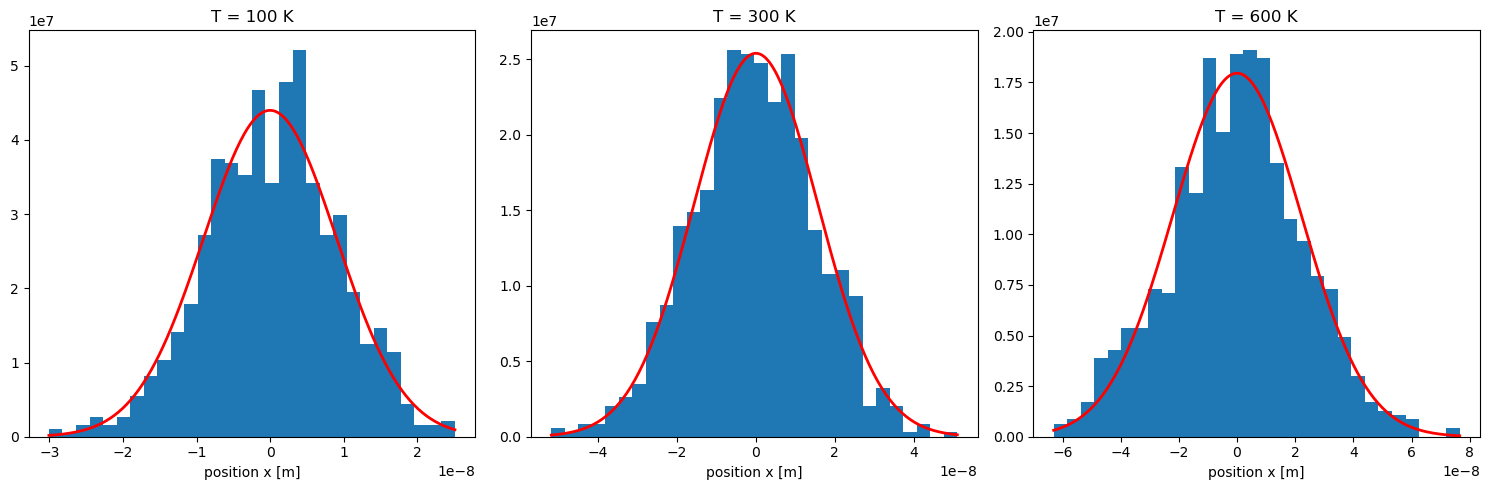

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 基本物理パラメータ (10μm粒子)
n = 1000
dt = 1.0*10**(-4)
steps = 50 
t_now = steps * dt

kB = 1.38*10**(-23)
r = 1.0*10**(-5)
rho = 2699
visc = 0.890*10**(-3)
m = rho * (4/3) * np.pi * r**3
q = visc * 6 * np.pi * r
beta = q / m

# 温度のリスト
T_list = [100, 300, 600]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, T in enumerate(T_list):
    ax = axes[i]
    D = (kB * T) / q
    
    data = []
    for _ in range(n):
        x, v = 0, 0
        for _ in range(steps):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v += dv
            x += v * dt
        data.append(x)
    
    # ヒストグラム
    ax.hist(data, bins=30, density=True)
    
    # 理論曲線
    x_theory = np.linspace(min(data), max(data), 200)
    sigma_theory = np.sqrt(2 * D * t_now)
    f_gauss = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-x_theory**2 / (2 * sigma_theory**2))
    ax.plot(x_theory, f_gauss, color='red', lw=2)
    
    ax.set_title(f"T = {T} K")
    ax.set_xlabel("position x [m]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

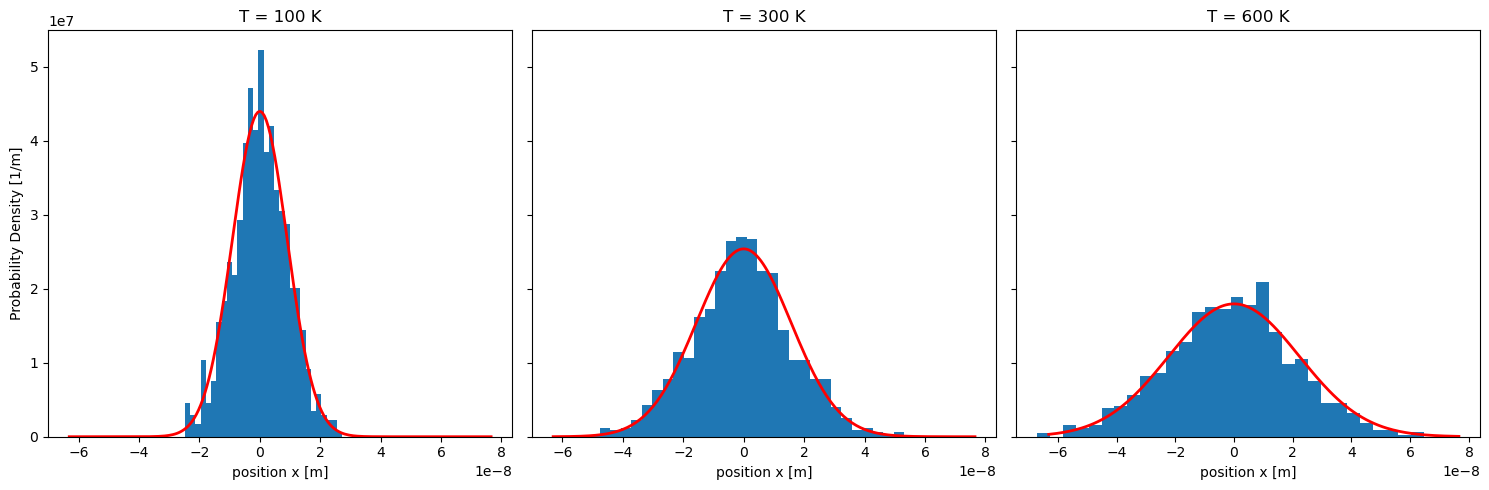

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 基本物理パラメータ (10μm粒子)
n = 1000
dt = 1.0*10**(-4)
steps = 50 
t_now = steps * dt

kB = 1.38*10**(-23)
r = 1.0*10**(-5)
rho = 2699
visc = 0.890*10**(-3)
m = rho * (4/3) * np.pi * r**3
q = visc * 6 * np.pi * r
beta = q / m

T_list = [100, 300, 600]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True) # 縦軸を共有

for i, T in enumerate(T_list):
    ax = axes[i]
    D = (kB * T) / q
    
    pos_data = []
    for _ in range(n):
        x, v = 0, 0
        for _ in range(steps):
            sigma = np.sqrt(2 * kB * T * q * dt)
            f_random = random.gauss(0, sigma)
            dv = -beta * v * dt + f_random / m
            v += dv
            x += v * dt
        pos_data.append(x)
    
    ax.hist(pos_data, bins=30, density=True)
    
    # 理論曲線
    x_theory = np.linspace(min(data), max(data), 200) 
    sigma_theory = np.sqrt(2 * D * t_now)
    f_gauss = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-x_theory**2 / (2 * sigma_theory**2))
    ax.plot(x_theory, f_gauss, color='red', lw=2, label='Theory')
    
    ax.set_title(f"T = {T} K")
    ax.set_xlabel("position x [m]")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if i == 0: ax.set_ylabel("Probability Density [1/m]")

plt.tight_layout()
plt.show()


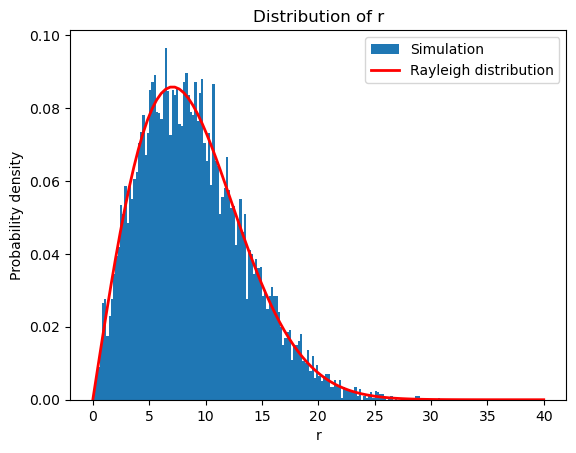

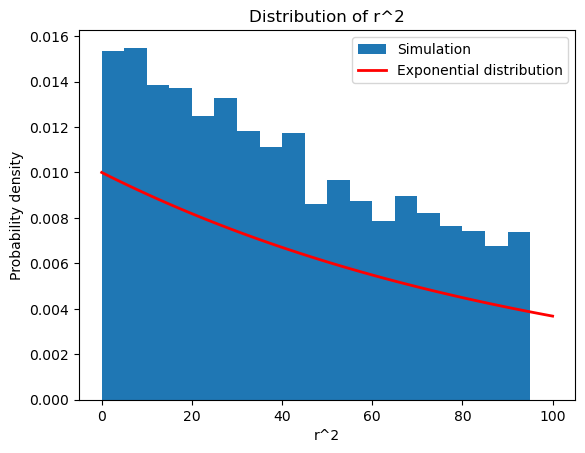

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng() #デフォルトの乱数発生アルゴリズム

n = 100   # 1回のランダムウォークのステップ数
N = 10000 #乱数の数

x_fin = np.zeros(N) #最終位置
y_fin = np.zeros(N)
r = np.zeros(N) #距離
r2 = np.zeros(N)

# ランダムウォーク
for i in range(N):
    x, y = 0.0, 0.0  # 初期位置は原点
    
    for _ in range(n):
        theta = np.random.uniform(0, 2*np.pi)  #θ
        x += np.cos(theta)
        y += np.sin(theta)
    
    x_fin[i] = x
    y_fin[i] = y
    r[i] = np.sqrt(x**2 + y**2)
    r2[i] = x**2 + y**2

#グラフを書く
bins_r = np.arange(0,40,0.2)
plt.hist(r,bins=bins_r,density=True,label="Simulation")

#レイリー分布
r_atai = np.linspace(0,40,100) #値
sigma = np.sqrt(n/2)  #σ=√(n/2)
rayleigh = (r_atai/sigma**2)*np.exp(-r_atai**2/(2*(sigma**2))) #レイリー

plt.plot(r_atai,rayleigh,'r',lw=2,label="Rayleigh distribution")
plt.xlabel("r")
plt.ylabel("Probability density")
plt.title("Distribution of r")
plt.legend()
plt.show()

#(b) r^2のヒストグラム
bins_r2 = np.arange(0,100,5)
plt.hist(r2,bins=bins_r2,density=True,label='Simulation')

#指数関数
r2_atai = np.linspace(0, 100, 100)
exp_dist = (1/n) * np.exp(-r2_atai / n)

plt.plot(r2_atai, exp_dist, 'r', lw=2,label="Exponential distribution")

plt.xlabel("r^2")
plt.ylabel("Probability density")
plt.title("Distribution of r^2")
plt.legend()
plt.show()
